# The Rounding Tax \U0001FA99
### Your model portfolio says 40% SPY. Your $3,000 account says four shares.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Every asset-allocation article in the world is written in percentages. Percentages assume you
can buy 3.7 shares. For most of investing history, and still today in most retirement plans and
most non-US brokerages, you cannot — so the portfolio you own is the rounded one.

> \U0001F4D3 **This is the plain-language layer.** The allocation algorithm, the drag/noise
> decomposition and the escapes are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does whole-share rounding matter? | Below about $25,000, yes, visibly. |
| Does it cost you money? | Much less than it costs you *precision*. |
| Why the difference? | Being overweight is as likely as underweight. It cancels. |
| What actually fixes it? | Holding fewer funds — more than fractional shares do. |

## 1 · The portfolio on paper

In [2]:
from roundingtax import data, strategy as st

px = data.load_prices()
target = dict(data.TARGET)
names = [t for t in target if t in px.columns]
panel = px[names].dropna()
last = panel.iloc[-1]
print(f"as-of {data.AS_OF} | {len(panel):,} sessions, "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
for t in names:
    print(f"  {t:6s} target {target[t]:>4.0%}   ${last[t]:8.2f} per share")
print(f"\none share of everything: ${st.one_share_cost(target, last):,.2f}")

as-of 2026-06-30 | 3,877 sessions, 2011-01-28 -> 2026-06-30
  SPY    target  40%   $  746.77 per share
  VXUS   target  20%   $   85.49 per share
  BND    target  25%   $   72.91 per share
  IJR    target   5%   $  148.31 per share
  VNQ    target   5%   $   96.43 per share
  GLD    target   5%   $  368.38 per share

one share of everything: $1,518.29


## 2 · The portfolio you can actually buy

In [3]:
for cap in (1000, 3000, 10_000, 100_000):
    a = st.whole_share_allocation(target, last, float(cap))
    e = st.allocation_error(a)
    print(f"\n${cap:,} account:")
    for t in names:
        sh = a["shares"].get(t, 0.0)
        print(f"  {t:6s} {sh:6.0f} shares = ${sh * last[t]:9,.2f}  "
              f"= {a['weights'].get(t, 0):5.1%}   (target {target[t]:.0%})")
    print(f"  cash left over: ${a['cash']:,.2f} ({e['cash_share']:.1%})")
    print(f"  total miss: {e['l1']:.1%}")


$1,000 account:
  SPY         0 shares = $     0.00  =  0.0%   (target 40%)
  VXUS        3 shares = $   256.47  = 25.6%   (target 20%)
  BND         4 shares = $   291.64  = 29.2%   (target 25%)
  IJR         1 shares = $   148.31  = 14.8%   (target 5%)
  VNQ         1 shares = $    96.43  =  9.6%   (target 5%)
  GLD         0 shares = $     0.00  =  0.0%   (target 5%)
  cash left over: $207.15 (20.7%)
  total miss: 69.3%

$3,000 account:
  SPY         1 shares = $   746.77  = 24.9%   (target 40%)
  VXUS        8 shares = $   683.92  = 22.8%   (target 20%)
  BND        11 shares = $   802.02  = 26.7%   (target 25%)
  IJR         1 shares = $   148.31  =  4.9%   (target 5%)
  VNQ         2 shares = $   192.86  =  6.4%   (target 5%)
  GLD         1 shares = $   368.38  = 12.3%   (target 5%)
  cash left over: $57.74 (1.9%)
  total miss: 28.4%

$10,000 account:
  SPY         5 shares = $ 3,733.85  = 37.3%   (target 40%)
  VXUS       24 shares = $ 2,051.76  = 20.5%   (target 20%)
  BND   

> \U0001F52C **For the quants.** The allocator uses **largest remainder**, not naive flooring.
> Flooring each position independently would leave far more cash idle and would overstate the
> cost of being small — the direction this study must not err in.

## 3 · How big does an account need to be?

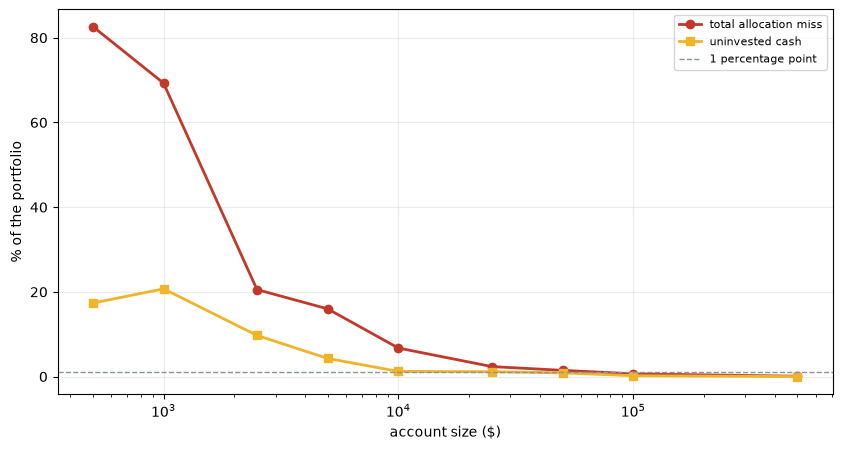

one share of each:                   $     1,518
enough to hit every weight within 1pp: $    38,857


In [4]:
ev = st.error_vs_capital(target, last)
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(ev.index, ev["l1_error"] * 100, "o-", lw=2, color="#c0392b",
            label="total allocation miss")
ax.semilogx(ev.index, ev["cash_share"] * 100, "s-", lw=2, color="#f0b429",
            label="uninvested cash")
ax.axhline(1, ls="--", color="#8b949e", lw=1, label="1 percentage point")
ax.set_xlabel("account size ($)"); ax.set_ylabel("% of the portfolio")
ax.legend(fontsize=8)
plt.show()
print(f"one share of each:                   ${st.one_share_cost(target, last):>10,.0f}")
print(f"enough to hit every weight within 1pp: ${st.min_viable_capital(target, last):>10,.0f}")

Those two numbers are usually confused. Buying one share of everything gets you *a* portfolio.
Its weights are decided by the share prices, not by you.

## 4 · Twenty years later, what did it cost?

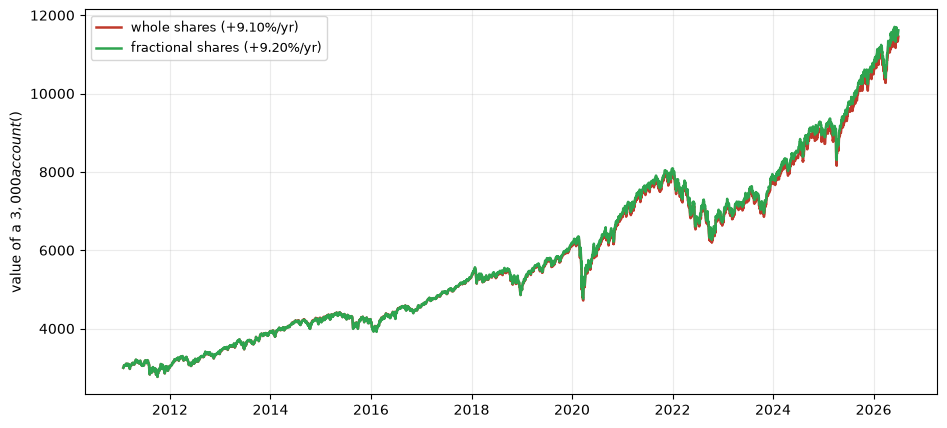

gap: -0.10%/yr, tracking error 0.28%/yr
after 15 years the whole-share account ended -1.4% vs the ideal


In [5]:
cash_rate = px[data.CASH].pct_change().reindex(panel.index).fillna(0.0)
cmp = st.compare_to_ideal(panel, target, 3000.0, cash_rate, cost_bps=5.0)
whole = st.rebalance_simulation(panel, target, 3000.0, cash_rate, cost_bps=5.0)
frac = st.rebalance_simulation(panel, target, 3000.0, cash_rate, cost_bps=5.0,
                               allow_fractional=True)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(whole["value"].index, whole["value"], lw=1.8, color="#c0392b",
        label=f"whole shares ({cmp['cagr_whole']:+.2%}/yr)")
ax.plot(frac["value"].index, frac["value"], lw=1.8, color="#2ea44f",
        label=f"fractional shares ({cmp['cagr_fractional']:+.2%}/yr)")
ax.set_ylabel("value of a $3,000 account ($)"); ax.legend(fontsize=9)
plt.show()
print(f"gap: {cmp['cagr_gap']:+.2%}/yr, tracking error {cmp['tracking_error']:.2%}/yr")
print(f"after {cmp['years']:.0f} years the whole-share account ended "
      f"{cmp['final_gap_pct']:+.1%} vs the ideal")

## 5 · The bit that matters: is that a cost, or a coin flip?

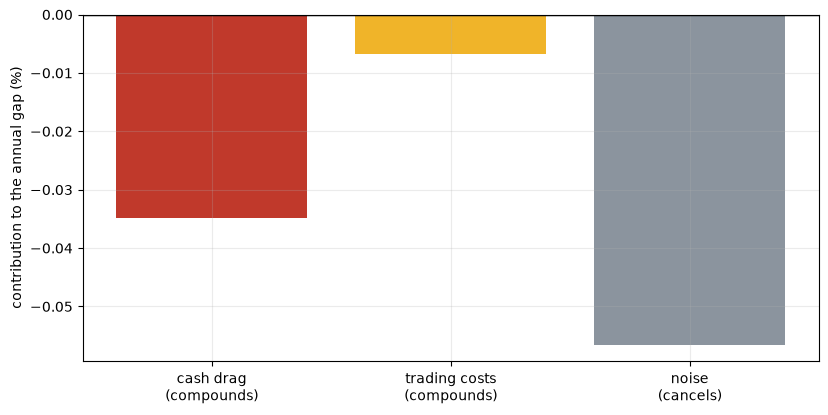

cash drag        -0.035%/yr
trading costs    -0.007%/yr
noise            -0.057%/yr

total gap -0.098%/yr, of which 42% is genuine drag


In [6]:
dec = st.decompose_shortfall(cmp, 0.02, 0.06)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
parts = ["cash_drag", "trading_costs", "unexplained_noise"]
labels = ["cash drag\n(compounds)", "trading costs\n(compounds)",
          "noise\n(cancels)"]
colors = ["#c0392b", "#f0b429", "#8b949e"]
ax.bar(labels, [dec[p] * 100 for p in parts], color=colors)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("contribution to the annual gap (%)")
plt.show()
for p, l in zip(parts, labels):
    print(f"{l.splitlines()[0]:16s} {dec[p]:+.3%}/yr")
print(f"\ntotal gap {dec['total_gap']:+.3%}/yr, of which {dec['drag_share']:.0%} is genuine "
      f"drag")

The grey bar is the one everyone counts as a cost. It is not: being accidentally overweight
equities is as likely as accidentally underweight, and across many accounts and many years it
averages out. Only the red and amber bars are money you never see again.

## 6 · What actually helps

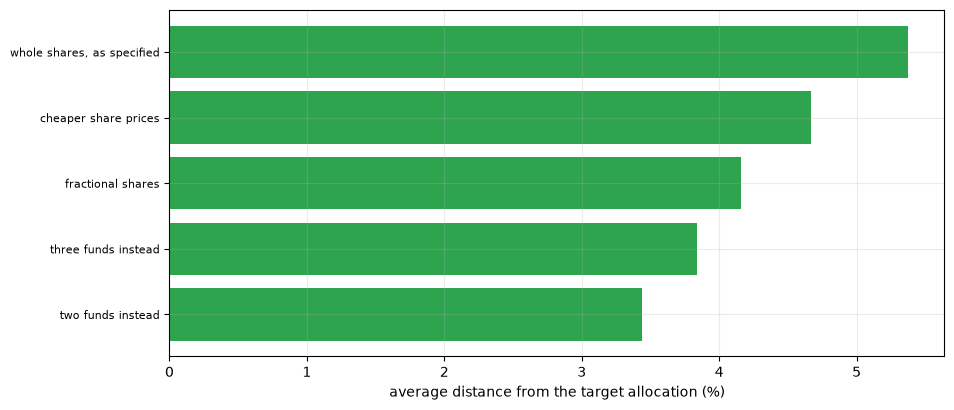

                             cagr    vol  mean_cash_share  mean_l1_error  n_positions  cost_share
variant                                                                                          
whole shares, as specified 0.0910 0.1172           0.0058         0.0537            6      0.0011
fractional shares          0.0920 0.1181          -0.0000         0.0416            6      0.0011
three funds instead        0.0889 0.1147           0.0131         0.0384            3      0.0009
two funds instead          0.0946 0.1026           0.0130         0.0344            2      0.0009
cheaper share prices       0.0898 0.1198           0.0031         0.0467            6      0.0010


In [7]:
esc_panel = px[[c for c in px.columns if c != data.CASH]].dropna()
swaps = {data.CORE: data.CHEAP_CORE} if data.CHEAP_CORE in px.columns else None
esc = st.escape_table(esc_panel, target, 3000.0, cash_rate, swaps, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(10, 4.5))
e = esc.sort_values("mean_l1_error")
ax.barh(range(len(e)), e["mean_l1_error"] * 100, color="#2ea44f")
ax.set_yticks(range(len(e))); ax.set_yticklabels(e.index, fontsize=8)
ax.set_xlabel("average distance from the target allocation (%)")
plt.show()
print(esc.round(4).to_string())

## 7 · The verdict

**Signal: Weak.** A **$3,000** account holding the 6-fund target could not place it: the achieved weights missed the plan by **5.4%** in total absolute terms on average, worst position off by 17.2%, and **0.6%** of the account sat in uninvested residue. Against a fractional-share portfolio running the identical plan, the tracking error was **0.28%/yr** over 15 years. Two numbers put that in proportion. One share of each fund costs $1,518 — the figure usually quoted — but the account that actually *hits* the target weights to within one percentage point is **$38,857**, an order of magnitude more, because owning one of everything gives you a portfolio whose weights are set by share prices rather than by your plan.

**Tradability: Partial.** But the shortfall is mostly **noise, not drag**, and the difference decides the advice. Over 15 years the whole-share portfolio compounded at +9.10% against the fractional ideal's +9.20% — a gap of **-0.10%/yr**, of which cash drag explains -0.03% and trading costs -0.01%, leaving -0.06% that is simply which way the dice fell. Allocation error is mean-zero — you are as likely to be overweight as under — so it produces tracking error without an expected cost; only the cash residue is one-directional. The fix that works is not fractional shares but **fewer funds**: cutting the target to its three largest positions dropped the allocation error from 5.4% to **3.4%**.

## 8 · Going further \U0001F6AA

- **Regular contributions fix most of this.** New money can be directed at whichever sleeve is
  furthest below target, which is a free rebalancing mechanism. This study deliberately omits
  it, and it is the single largest omission.
- **Fractional shares** now exist at most large US brokers — but not in most retirement plans,
  most non-US brokers, or inside most wrappers.
- **A target-date fund** solves the whole problem by doing the rounding inside a single share,
  at the cost of an expense ratio. Comparing that fee against the numbers above is the real
  decision.